<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq

In [3]:
from fastai.vision.all import *

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

In [6]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

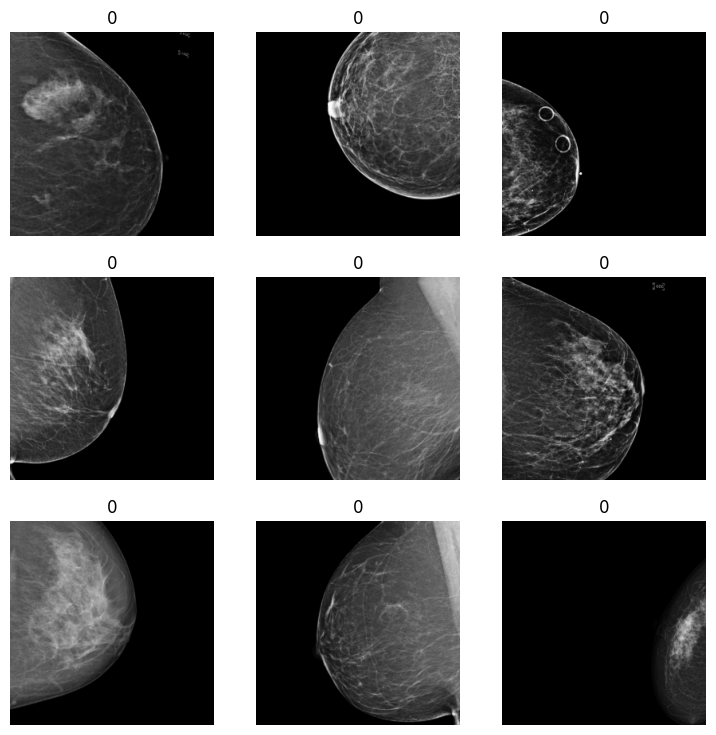

In [7]:
dls = db.dataloaders(imagesPath, bs=128)
dls.show_batch()

### Resnet 50

In [9]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='modelResnet50')  
]

In [13]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()


SuggestedLRs(valley=0.004365158267319202)

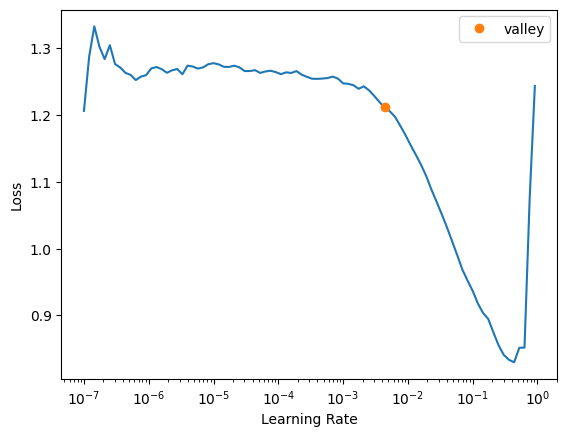

In [14]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.134718,0.111616,0.977699,0.000000,0.000000,0.000000,08:48


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11161649227142334.


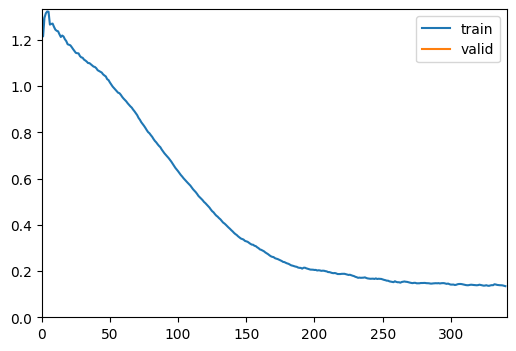

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.105737,0.135013,0.977699,0.000000,0.000000,0.000000,09:04
1,0.113950,0.282286,0.977699,0.000000,0.000000,0.000000,09:04
2,0.112792,0.106755,0.977699,0.000000,0.000000,0.000000,09:10
3,0.099973,0.108033,0.977699,0.000000,0.000000,0.000000,09:09
4,0.098181,0.109675,0.977699,0.000000,0.000000,0.000000,09:02
5,0.098691,0.103121,0.977699,0.000000,0.000000,0.000000,08:51
6,0.096698,0.097624,0.977699,0.500000,0.004098,0.008130,08:40
7,0.089409,0.101533,0.977424,0.440000,0.045082,0.081784,08:49
8,0.088965,0.099235,0.977333,0.437500,0.057377,0.101449,09:03
9,0.088852,0.097297,0.977699,0.500000,0.036885,0.068702,08:59


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1350134015083313.


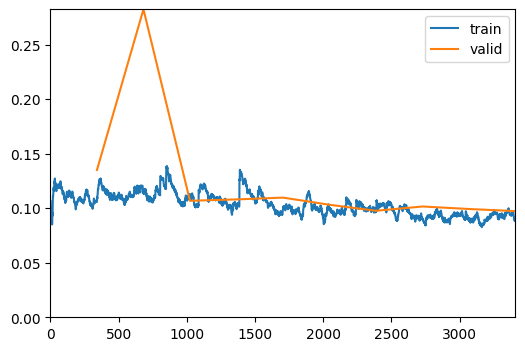

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.10675548017024994.


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.10312093794345856.
Better model found at epoch 6 with valid_loss value: 0.09762357920408249.
Better model found at epoch 9 with valid_loss value: 0.09729737788438797.


In [15]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 40 mins.